# Kudge Solver/Judge Difficulty Comparison

Load Kudge K-factor item difficulty JSONs and keep each item's per-model scores. `kudge_challenge` is treated as solver-side; `kudge_judge` is treated as judge-side.


In [33]:
from pathlib import Path
import json

import pandas as pd
from scipy.stats import spearmanr
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 240)


## Choose K And Resolve Paths


In [34]:
K = 2  # choose 1 or 2


def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "K-Factor").exists() and (candidate / "benchmarks").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing K-Factor/ and benchmarks/")


REPO_ROOT = find_repo_root()
print(f"Repo root: {REPO_ROOT}")

solver_json_path = REPO_ROOT / "K-Factor" / "results" / "kudge_challenge" / "kudge_challenge_kfactor_item_difficulties_with_laplace_uncertainty.json"
judge_json_path = REPO_ROOT / "K-Factor" / "results" / "kudge_judge" / "kudge_judge_kfactor_item_difficulties_with_laplace_uncertainty.json"
solver_fit_summary_path = REPO_ROOT / "K-Factor" / "results" / "kudge_challenge" / "kudge_challenge_kfactor_fit_summary.csv"
judge_fit_summary_path = REPO_ROOT / "K-Factor" / "results" / "kudge_judge" / "kudge_judge_kfactor_fit_summary.csv"

out_dir = REPO_ROOT / "K-Factor" / "results" / "kudge_solver_judge_comparison"
out_dir.mkdir(parents=True, exist_ok=True)

for path in [solver_json_path, judge_json_path, solver_fit_summary_path, judge_fit_summary_path]:
    print(path.relative_to(REPO_ROOT), path.exists())


Repo root: /Users/dkoffical/Documents/GitHub/cs321m_project
K-Factor/results/kudge_challenge/kudge_challenge_kfactor_item_difficulties_with_laplace_uncertainty.json True
K-Factor/results/kudge_judge/kudge_judge_kfactor_item_difficulties_with_laplace_uncertainty.json True
K-Factor/results/kudge_challenge/kudge_challenge_kfactor_fit_summary.csv True
K-Factor/results/kudge_judge/kudge_judge_kfactor_fit_summary.csv True


## Fit Summaries


In [35]:
solver_fit_summary = pd.read_csv(solver_fit_summary_path)
judge_fit_summary = pd.read_csv(judge_fit_summary_path)

def choose_best_k(summary):
    return (
        summary
        .sort_values(["auc", "ece", "loss"], ascending=[False, True, True])
        .iloc[0]
    )

solver_best = choose_best_k(solver_fit_summary)
judge_best = choose_best_k(judge_fit_summary)

print(f"Solver-side best k by AUC (tie-break ECE/loss): k={int(solver_best['k'])}")
print(f"Judge-side best k by AUC (tie-break ECE/loss):  k={int(judge_best['k'])}")
print(f"Currently loading K={K}")

print()
print("Solver fit summary")
display(solver_fit_summary.round(4))

print("Judge fit summary")
display(judge_fit_summary.round(4))

solver_fit_summary.to_csv(out_dir / "kudge_solver_kfactor_fit_summary.csv", index=False)
judge_fit_summary.to_csv(out_dir / "kudge_judge_kfactor_fit_summary.csv", index=False)


Solver-side best k by AUC (tie-break ECE/loss): k=2
Judge-side best k by AUC (tie-break ECE/loss):  k=2
Currently loading K=2

Solver fit summary


,k,loss,auc,log_likelihood,brier,ece
0,1,0.3019,0.9216,-0.3019,0.1012,0.0253
1,2,0.2169,0.9511,-0.2168,0.0706,0.0220


Judge fit summary


,k,loss,auc,log_likelihood,brier,ece
0,1,0.3694,0.8420,-0.3693,0.1257,0.0270
1,2,0.2667,0.8878,-0.2667,0.0888,0.0284


## Load Item Difficulties And Scores


In [36]:
def load_kfactor_fit(json_path, k, score_col):
    with open(json_path) as f:
        payload = json.load(f)

    fit_key = f"k{k}"
    if fit_key not in payload["fits"]:
        raise KeyError(f"{json_path} does not contain {fit_key}; available={list(payload['fits'])}")

    df = pd.DataFrame(payload["fits"][fit_key])
    df["item_id"] = df["item_id"].astype(str)
    df = df.rename(columns={"scores": score_col})
    return df, payload


solver_items, solver_payload = load_kfactor_fit(solver_json_path, K, "solver_scores")
judge_items, judge_payload = load_kfactor_fit(judge_json_path, K, "judge_scores")

print(f"solver_items: {solver_items.shape}")
print(f"judge_items:  {judge_items.shape}")

print()
print("Solver columns:")
print(list(solver_items.columns))

print()
print("Judge columns:")
print(list(judge_items.columns))


solver_items.to_csv(out_dir / f"kudge_k{K}_solver_items.csv", index=False)
judge_items.to_csv(out_dir / f"kudge_k{K}_judge_items.csv", index=False)
solver_items.to_json(out_dir / f"kudge_k{K}_solver_items.json", orient="records", indent=2, force_ascii=False)
judge_items.to_json(out_dir / f"kudge_k{K}_judge_items.json", orient="records", indent=2, force_ascii=False)


solver_items: (381, 18)
judge_items:  (381, 18)

Solver columns:
['item_id', 'difficulty', 'difficulty_centered', 'easiness_z', 'loading_factor_1', 'loading_factor_2', 'dominant_factor', 'item_id_meta', 'subset', 'gold', 'prompt', 'chosen', 'rejected', 'difficulty_laplace_se', 'difficulty_centered_laplace_se', 'difficulty_centered_laplace_lo', 'difficulty_centered_laplace_hi', 'solver_scores']

Judge columns:
['item_id', 'difficulty', 'difficulty_centered', 'easiness_z', 'loading_factor_1', 'loading_factor_2', 'dominant_factor', 'item_id_meta', 'subset', 'gold', 'prompt', 'chosen', 'rejected', 'difficulty_laplace_se', 'difficulty_centered_laplace_se', 'difficulty_centered_laplace_lo', 'difficulty_centered_laplace_hi', 'judge_scores']


## Preview Scores


In [37]:
preview_cols = [
    "item_id",
    "subset",
    "gold",
    "difficulty_centered",
    "difficulty_centered_laplace_se",
    "dominant_factor",
    "prompt",
    "solver_scores",
]
display(solver_items[[c for c in preview_cols if c in solver_items.columns]].head())

preview_cols = [
    "item_id",
    "subset",
    "gold",
    "difficulty_centered",
    "difficulty_centered_laplace_se",
    "dominant_factor",
    "prompt",
    "judge_scores",
]
display(judge_items[[c for c in preview_cols if c in judge_items.columns]].head())


,item_id,subset,gold,difficulty_centered,difficulty_centered_laplace_se,dominant_factor,prompt,solver_scores
0,730,Korean-Hard,A,11.461952,0.958718,factor_1,"### 질문:\n25°С에서 100 cm3 전체 부피에 0.1 g Fe(OH)3를 녹이고 싶습니다. 용액을 준비하는 데 필요한 0.1 M 일염기성 강산의 최소 부피(cm3)는 얼마이며, 생성된 용액의 pH는 얼마입니까?\n### 선택지:\nA. pH 2.69; 30.09 cm3\nB. pH 2.04; 28.05 cm3\nC. pH 4.94; 20.40 cm3\nD. pH 3.16; 32.14 cm3","{'claudehaiku4520251001': 0.0, 'claudeopus47': 1.0, 'claudesonnet46': 0.0, 'ministral3b': 0.0, 'ministral8b': 1.0, 'mistral14b': 0.0, 'qwen3508b': 0.0, 'qwen3527b': 0.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 1.0}"
1,12,Korean-Easy,D,10.763064,2.597994,factor_2,"다음 문제를 읽고, 정답으로 가장 알맞은 것을 고르시요.\n### 질문: f: R -> R이 르벡 적분이 가능한 유계함수이면 다음 중 반드시 참인 명제는 무엇입니까?\n### 선택지: \n a) f는 리만 적분이 가능하다.\n b) 모든 x \in E에서 f가 미분 불가능할 때 R의 계수 가능한 무한 집합 E가 없다.\n c) 모든 x \in E에서 f가 미분 불가능할 때 R의 계수 불가능한 부분 집합 E가 없다.\n ...","{'claudehaiku4520251001': 1.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral3b': 0.0, 'ministral8b': 0.0, 'mistral14b': 0.0, 'qwen3508b': 0.0, 'qwen3527b': 0.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 1.0}"
2,650,Korean-Hard,C,10.762997,2.602623,factor_2,"### 질문:\n연구자들은 지구와 유사한 두 개의 행성, 행성_1과 행성_2의 통과를 탐지하려 하고 있습니다. 그들은 관측 시간이 제한되어 있어 통과할 확률이 가장 높은 행성을 관측하고 싶어합니다. 이 두 행성은 이미 RV 방법을 통해 탐지되어 최소 질량과 궤도 주기를 알고 있습니다. 두 행성이 동일한 질량을 가지고 있지만, 행성_1의 궤도 주기는 행성_2보다 세 배 짧습니다. 흥미롭게도 두 행성 모두 원형 궤도를 가지...","{'claudehaiku4520251001': 1.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral3b': 0.0, 'ministral8b': 0.0, 'mistral14b': 0.0, 'qwen3508b': 0.0, 'qwen3527b': 0.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 1.0}"
3,665,Korean-Hard,C,9.068446,1.961619,factor_2,"### 질문:\n천문학자들은 TTV 방법을 통해 발견된 원형 궤도의 세 외계행성(행성1, 행성2, 행성3) 시스템을 연구하고 있다. 그들은 행성1과 행성2 사이의 평형 온도 비율이 대략 1.4이며, 행성2와 행성3 사이의 비율은 약 2.3임을 발견했다. 또한, 행성1과 행성2 사이의 질량 비율은 대략 1.15, 행성2와 행성3 사이의 비율은 약 1.35임을 발견했다. 세 행성 모두의 반사율이 지구와 유사한 0.3이라면,...","{'claudehaiku4520251001': 1.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral3b': 0.0, 'ministral8b': 0.0, 'mistral14b': 1.0, 'qwen3508b': 0.0, 'qwen3527b': 1.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 1.0}"
4,725,Korean-Hard,C,8.693969,1.746272,factor_2,"### 질문:\n실험실에서 화학자는 이름이 없는 병 안에 있는 흰색 고체를 발견합니다. 그는 액체를 식별하기 위해 다음의 스펙트럼 정보를 수집합니다. 제공된 정보를 사용하여 확인되지 않은 약물의 합리적인 구조를 제안하십시오.\n질량: 분자 이온 피크 m/z = 156 (100%)\nm/z = 158에서 피크 (32%)\nIR: 3500-2700 cm^-1에서 넓은 피크, 1720 cm^-1에서 강한 날카로운 피크\n1H...","{'claudehaiku4520251001': 1.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral3b': 0.0, 'ministral8b': 1.0, 'mistral14b': 1.0, 'qwen3508b': 0.0, 'qwen3527b': 1.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 1.0}"


,item_id,subset,gold,difficulty_centered,difficulty_centered_laplace_se,dominant_factor,prompt,judge_scores
0,655,Korean-Hard,B,9.356414,1.682755,factor_1,### 질문:\n한 학생은 전기화학 강의 중에 잠들어 시험에서 다음과 같은 불완전한 문장에 직면하게 되었음을 후회합니다:\n열역학적으로 산소는 염기성 용액에서 …… 산화제입니다. 반응 속도적으로 산소는 산성 용액에서 …… 반응합니다.\n약한/강한 및 빠른/느린 조합 중 어느 것이 맞습니까?\n### 선택사항:\nA. 강한 – 빠른\nB. 약한 – 빠른\nC. 약한 – 느린\nD. 강한 – 느린\n### 정답:,"{'claudehaiku4520251001': 0.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral14b': 0.0, 'ministral3b': 0.0, 'ministral8b': 0.0, 'qwen3508b': 0.0, 'qwen3527b': 1.0, 'qwen352b': 0.0, 'qwen354b': 1.0, 'qwen359b': 1.0}"
1,671,Korean-Hard,B,8.632475,3.130483,factor_2,"### 질문:\n동료가 사차원 시공간에서 새로운 양자장 이론을 고안했고, 그 이론에서 특정 고차 루프 다이어그램의 정규화를 탐구하고 있습니다. 그들의 책상 위에 낙서로 적힌 메모를 엿보니, 페인만 다이어그램이 있고 그 옆에 ""크기 추정""이라는 단어와 함께 일련의 물리 상수, 숫자, 에너지 규모 사이의 비율이 있습니다. 기호는 다음과 같습니다: alpha^3 * g^2 sqrt(2) * 8 * 1/(4pi)^6 * (Q/...","{'claudehaiku4520251001': 1.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral14b': 0.0, 'ministral3b': 0.0, 'ministral8b': 0.0, 'qwen3508b': 0.0, 'qwen3527b': 1.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 1.0}"
2,145,Korean-Easy,B,8.481114,2.270303,factor_1,"다음 문제를 읽고, 정답으로 가장 알맞은 것을 고르시요.\n### 질문: 이산화황은 촉매 존재 시 산소와 반응하여 3산화항을 형성합니다. 특정 온도에서 평형 상수 Kp는 3.0 × 10^22입니다. 2.0리터 플라스크에는 SO3 0.789 atm Hg 압력을 생성하기에 충분한 SO3가 포함되어 있습니다. 반응이 평형 상태가 된 후 O2의 부분 압력은?\n### 선택지: \n a) 2.88 × 10^-6 torr\n b)...","{'claudehaiku4520251001': 0.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral14b': 0.0, 'ministral3b': 0.0, 'ministral8b': 0.0, 'qwen3508b': 0.0, 'qwen3527b': 1.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 1.0}"
3,196,Korean-Easy,A,7.250606,2.229388,factor_1,"다음 문제를 읽고, 정답으로 가장 알맞은 것을 고르시요.\n### 질문: 구리 동전을 연소시킬 수 있는 가장 쉬운 방법은 어떤 것입니까?\n### 선택지: \n a) 도가니 집게로 구리 동전을 잡고 분젠식 버너 화염으로 직접 가열합니다.\n b) (A) 방법을 사용하되, 산소아세틸렌 토치를 사용하여 더 높은 온도로 가열합니다.\n c) 구리 동전을 매우 작은 분진 크기의 입자로 분쇄하여 분젠식 버너 화염으로 분사합니다....","{'claudehaiku4520251001': 1.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral14b': 0.0, 'ministral3b': 0.0, 'ministral8b': 0.0, 'qwen3508b': 0.0, 'qwen3527b': 1.0, 'qwen352b': 1.0, 'qwen354b': 1.0, 'qwen359b': 1.0}"
4,271,Korean-Easy,B,7.095734,1.433681,factor_1,"다음 문제를 읽고, 정답으로 가장 알맞은 것을 고르시요.\n### 질문: 일반적으로 다른 국가보다 기후와 자원의 다양성을 갖춘 나라는?\n### 선택지: \n a) 천공된 국가\n b) 조각난 국가\n c) 영토가 길게 뻗은 국가\n d) 회랑 포함 국가\n### 풀이:","{'claudehaiku4520251001': 1.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral14b': 0.0, 'ministral3b': 0.0, 'ministral8b': 0.0, 'qwen3508b': 0.0, 'qwen3527b': 1.0, 'qwen352b': 0.0, 'qwen354b': 1.0, 'qwen359b': 1.0}"


## Join Solver And Judge Items


In [38]:
def prefix_except(df, prefix, keep_cols):
    keep_cols = set(keep_cols)
    return df.rename(columns={col: f"{prefix}_{col}" for col in df.columns if col not in keep_cols})


solver_for_join = prefix_except(solver_items, "solver", keep_cols=["solver_scores"])
judge_for_join = prefix_except(judge_items, "judge", keep_cols=["judge_scores"])

paired_items = solver_for_join.merge(
    judge_for_join,
    left_on="solver_item_id",
    right_on="judge_item_id",
    how="inner",
    validate="one_to_one",
)

print(f"paired_items: {paired_items.shape}")
display(paired_items.head())


paired_items.to_csv(out_dir / f"kudge_k{K}_paired_items.csv", index=False)
paired_items.to_json(out_dir / f"kudge_k{K}_paired_items.json", orient="records", indent=2, force_ascii=False)


paired_items: (381, 36)


,solver_item_id,solver_difficulty,solver_difficulty_centered,solver_easiness_z,solver_loading_factor_1,solver_loading_factor_2,solver_dominant_factor,solver_item_id_meta,solver_subset,solver_gold,solver_prompt,solver_chosen,solver_rejected,solver_difficulty_laplace_se,solver_difficulty_centered_laplace_se,solver_difficulty_centered_laplace_lo,solver_difficulty_centered_laplace_hi,solver_scores,judge_item_id,judge_difficulty,judge_difficulty_centered,judge_easiness_z,judge_loading_factor_1,judge_loading_factor_2,judge_dominant_factor,judge_item_id_meta,judge_subset,judge_gold,judge_prompt,judge_chosen,judge_rejected,judge_difficulty_laplace_se,judge_difficulty_centered_laplace_se,judge_difficulty_centered_laplace_lo,judge_difficulty_centered_laplace_hi,judge_scores
0,730,11.347257,11.461952,-11.347257,-6.959016,-1.540627,factor_1,730,Korean-Hard,A,"### 질문:\n25°С에서 100 cm3 전체 부피에 0.1 g Fe(OH)3를 녹이고 싶습니다. 용액을 준비하는 데 필요한 0.1 M 일염기성 강산의 최소 부피(cm3)는 얼마이며, 생성된 용액의 pH는 얼마입니까?\n### 선택지:\nA. pH 2.69; 30.09 cm3\nB. pH 2.04; 28.05 cm3\nC. pH 4.94; 20.40 cm3\nD. pH 3.16; 32.14 cm3","Fe(OH)3 + 3H^+ = Fe^3+ + 3 H2O \n철 0.1g을 100 cm3 용액에 녹였을 때, Fe(III) 농도는 (0.1x1000) / (106.9x100) = 9.35x10^-3 M가 됩니다. \n9.35x10^-3 M Fe(III) 농도가 가능할 때 최대 수산화 이온 농도는 용해도 곱 상수를 이용하여 결정됩니다: Ksp = [Fe3+] [OH^-]^3 = 9.35x10^-3 x [OH^-]^3 =...","0.1 M 단염기성 강산의 최소 부피를 결정하여 0.1 g의 Fe(OH)3을 녹이고 용액의 결과 pH를 계산하기 위해 우리는 다음과 같이 계산을 시작합니다:\n\n1. **Fe(OH)3의 몰 질량**:\n - 철 (Fe) = 55.85 g/mol\n - 산소 (O) = 16.00 g/mol (산소 원자 3개)\n - 수소 (H) = 1.01 g/mol (수소 원자 3개)\n\n 따라서, Fe(OH)3의 몰...",0.952697,0.958718,9.582866,13.341039,"{'claudehaiku4520251001': 0.0, 'claudeopus47': 1.0, 'claudesonnet46': 0.0, 'ministral3b': 0.0, 'ministral8b': 1.0, 'mistral14b': 0.0, 'qwen3508b': 0.0, 'qwen3527b': 0.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 1.0}",730,2.760121,3.502955,-2.760121,0.526945,-5.474298,factor_2,730,Korean-Hard,A,"### 질문:\n25°С에서 100 cm3 전체 부피에 0.1 g Fe(OH)3를 녹이고 싶습니다. 용액을 준비하는 데 필요한 0.1 M 일염기성 강산의 최소 부피(cm3)는 얼마이며, 생성된 용액의 pH는 얼마입니까?\n### 선택지:\nA. pH 2.69; 30.09 cm3\nB. pH 2.04; 28.05 cm3\nC. pH 4.94; 20.40 cm3\nD. pH 3.16; 32.14 cm3","Fe(OH)3 + 3H^+ = Fe^3+ + 3 H2O \n철 0.1g을 100 cm3 용액에 녹였을 때, Fe(III) 농도는 (0.1x1000) / (106.9x100) = 9.35x10^-3 M가 됩니다. \n9.35x10^-3 M Fe(III) 농도가 가능할 때 최대 수산화 이온 농도는 용해도 곱 상수를 이용하여 결정됩니다: Ksp = [Fe3+] [OH^-]^3 = 9.35x10^-3 x [OH^-]^3 =...","0.1 M 단염기성 강산의 최소 부피를 결정하여 0.1 g의 Fe(OH)3을 녹이고 용액의 결과 pH를 계산하기 위해 우리는 다음과 같이 계산을 시작합니다:\n\n1. **Fe(OH)3의 몰 질량**:\n - 철 (Fe) = 55.85 g/mol\n - 산소 (O) = 16.00 g/mol (산소 원자 3개)\n - 수소 (H) = 1.01 g/mol (수소 원자 3개)\n\n 따라서, Fe(OH)3의 몰...",1.105721,1.107815,1.331638,5.674273,"{'claudehaiku4520251001': 1.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral14b': 1.0, 'ministral3b': 0.0, 'ministral8b': 1.0, 'qwen3508b': 0.0, 'qwen3527b': 1.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 0.0}"
1,12,10.648369,10.763064,-10.648369,-1.402219,-4.446486,factor_2,12,Korean-Easy,D,"다음 문제를 읽고, 정답으로 가장 알맞은 것을 고르시요.\n### 질문: f: R -> R이 르벡 적분이 가능한 유계함수이면 다음 중 반드시 참인 명제는 무엇입니까?\n### 선택지: \n a) f는 리만 적분이 가능하다.\n b) 모든 x \in E에서 f가 미분 불가능할 때 R의 계수 가능한 무한 집합 E가 없다.\n c) 모든 x \in E에서 f가 미분 불가능할 때 R의 계수 불가능한 부분 집합 E가 없다.\n ...","주어진 문제는 르벡 적분이 가능한 유계함수 \( f: \mathbb{R} \to \mathbb{R} \)에 대한 명제를 찾는 것입니다. 르벡 적분 가능한 함수는 일반적으로 다음과 같은 성질을 가집니다.\n\n### 르벡 적분의 성질\n1. **유계성**: 함수 \( f \)는 유계이므로, 어떤 상수 \( M > 0 \)이 존재하여 \( |f(x)| \leq M \)이 모든 \( x \in \mathbb{R} \)에 대해...","이 문제를 풀기 위해 르벡 적분 가능한 유계 함수 \( f: \mathbb{R} \to \mathbb{R} \)의 성질을 분석해 보겠습니다.\n\n### 르벡 적분 가능성\n르벡 적분 가능한 유계 함수는 거의 어디서나 미분 가능하며, 리만 적분 가능성과 밀접한 관련이 있습니다. 르벡 적분 가능성은 다음을 포함합니다:\n1. 함수는 거의 어디서나 연속입니다.\n2. 함수는 거의 어디서나 미분 가능합니다.\n3. 함수는 유...",2.601698,2.597994,5.670996,15.855133,"{'claudehaiku4520251001': 1.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral3b': 0.0, 'ministral8b': 0.0, 'mistral14b': 0.0, 'qwen3508b': 0.0, 'qwen3527b': 0.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 1.0}",12,0.170101,0.912935,-0.170101,-5.431150,0.038149,factor_1,12,Korean-Eas

In [39]:
paired_items.keys()

Index(['solver_item_id', 'solver_difficulty', 'solver_difficulty_centered', 'solver_easiness_z', 'solver_loading_factor_1', 'solver_loading_factor_2', 'solver_dominant_factor',
       'solver_item_id_meta', 'solver_subset', 'solver_gold', 'solver_prompt', 'solver_chosen', 'solver_rejected', 'solver_difficulty_laplace_se',
       'solver_difficulty_centered_laplace_se', 'solver_difficulty_centered_laplace_lo', 'solver_difficulty_centered_laplace_hi', 'solver_scores', 'judge_item_id',
       'judge_difficulty', 'judge_difficulty_centered', 'judge_easiness_z', 'judge_loading_factor_1', 'judge_loading_factor_2', 'judge_dominant_factor', 'judge_item_id_meta',
       'judge_subset', 'judge_gold', 'judge_prompt', 'judge_chosen', 'judge_rejected', 'judge_difficulty_laplace_se', 'judge_difficulty_centered_laplace_se',
       'judge_difficulty_centered_laplace_lo', 'judge_difficulty_centered_laplace_hi', 'judge_scores'],
      dtype='object')

## Bins Analysis


In [40]:
partone_table = paired_items[["solver_item_id", 
                      "solver_subset",
                      "solver_difficulty_centered",
                      "solver_difficulty_centered_laplace_se",
                      "solver_prompt",
                      "solver_gold",
                      "solver_scores",
                      "solver_chosen",
                      "solver_rejected",
                      "judge_scores"]]

partone_table.to_csv(out_dir / f"kudge_k{K}_partone_table_raw.csv", index=False)
partone_table.to_json(out_dir / f"kudge_k{K}_partone_table_raw.json", orient="records", indent=2, force_ascii=False)


In [41]:
partone_table = partone_table.copy()

partone_table["judge_score_mean"] = partone_table["judge_scores"].apply(
    lambda scores: pd.Series(scores).mean()
)

partone_table.to_csv(out_dir / f"kudge_k{K}_partone_table_with_judge_score_mean.csv", index=False)
partone_table.to_json(out_dir / f"kudge_k{K}_partone_table_with_judge_score_mean.json", orient="records", indent=2, force_ascii=False)


In [42]:
partone_table_sorted = partone_table.sort_values(
    "solver_difficulty_centered",
    ascending=False,
)

partone_table_sorted.to_csv(out_dir / f"kudge_k{K}_partone_table_sorted.csv", index=False)
partone_table_sorted.to_json(out_dir / f"kudge_k{K}_partone_table_sorted.json", orient="records", indent=2, force_ascii=False)


In [43]:
partone_table_sorted.keys()

Index(['solver_item_id', 'solver_subset', 'solver_difficulty_centered', 'solver_difficulty_centered_laplace_se', 'solver_prompt', 'solver_gold', 'solver_scores', 'solver_chosen',
       'solver_rejected', 'judge_scores', 'judge_score_mean'],
      dtype='object')

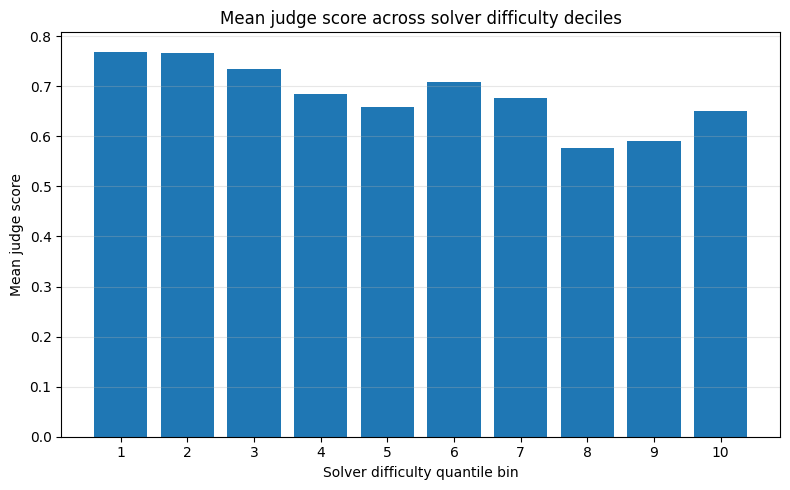

,difficulty_bin,solver_difficulty_mean,judge_score_mean,n_items
0,1,-4.954606,0.769231,39
1,2,-3.448359,0.765550,38
2,3,-2.156351,0.734450,38
3,4,-0.950497,0.684211,38
4,5,-0.339935,0.657895,38
5,6,0.302920,0.708134,38
6,7,0.729213,0.677033,38
7,8,1.412441,0.576555,38
8,9,3.018081,0.590909,38
9,10,6.517477,0.650718,38


In [44]:
import matplotlib.pyplot as plt

plot_df = partone_table.copy()

plot_df["difficulty_bin"] = pd.qcut(
    plot_df["solver_difficulty_centered"],
    q=10,
    labels=False,
    duplicates="drop",
)

bin_summary = (
    plot_df
    .groupby("difficulty_bin", observed=True)
    .agg(
        solver_difficulty_mean=("solver_difficulty_centered", "mean"),
        judge_score_mean=("judge_score_mean", "mean"),
        n_items=("solver_item_id", "count"),
    )
    .reset_index()
)

bin_summary["difficulty_bin"] = bin_summary["difficulty_bin"] + 1

plt.figure(figsize=(8, 5))
plt.bar(
    bin_summary["difficulty_bin"],
    bin_summary["judge_score_mean"],
)
plt.xlabel("Solver difficulty quantile bin")
plt.ylabel("Mean judge score")
plt.title("Mean judge score across solver difficulty deciles")
plt.xticks(bin_summary["difficulty_bin"])
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(out_dir / f"kudge_k{K}_difficulty_bin_summary.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / f"kudge_k{K}_difficulty_bin_summary.pdf", bbox_inches="tight")
plt.show()

display(bin_summary)

bin_summary.to_csv(out_dir / f"kudge_k{K}_difficulty_bin_summary.csv", index=False)
bin_summary.to_json(out_dir / f"kudge_k{K}_difficulty_bin_summary.json", orient="records", indent=2, force_ascii=False)


In [ ]:
# Per-judge-model view of Part 1.
# Each box shows the distribution across judge models within a solver difficulty bin.
import numpy as np
model_plot_df = partone_table.copy()
model_plot_df["difficulty_bin"] = pd.qcut(
    model_plot_df["solver_difficulty_centered"],
    q=10,
    labels=False,
    duplicates="drop",
)
model_plot_df["difficulty_bin"] = model_plot_df["difficulty_bin"] + 1

judge_model_rows = []
for _, row in model_plot_df.iterrows():
    scores = row["judge_scores"]
    if not isinstance(scores, dict):
        continue
    for judge_model, score in scores.items():
        if score is None or pd.isna(score):
            continue
        judge_model_rows.append({
            "difficulty_bin": int(row["difficulty_bin"]),
            "solver_item_id": row["solver_item_id"],
            "judge_model": judge_model,
            "judge_score": float(score),
        })

judge_model_scores = pd.DataFrame(judge_model_rows)
judge_model_bin_summary = (
    judge_model_scores
    .groupby(["difficulty_bin", "judge_model"], observed=True)
    .agg(
        judge_score_mean=("judge_score", "mean"),
        n_items=("solver_item_id", "count"),
    )
    .reset_index()
)

judge_model_bin_mean = (
    judge_model_bin_summary
    .groupby("difficulty_bin", observed=True)
    .agg(
        judge_score_mean=("judge_score_mean", "mean"),
        judge_score_sd=("judge_score_mean", "std"),
        n_judge_models=("judge_model", "count"),
    )
    .reset_index()
)

bins = sorted(judge_model_bin_summary["difficulty_bin"].unique())
box_values = [
    judge_model_bin_summary.loc[
        judge_model_bin_summary["difficulty_bin"] == bin_id,
        "judge_score_mean",
    ].dropna().to_numpy()
    for bin_id in bins
]

rng = np.random.default_rng(123)
plot_x = judge_model_bin_summary["difficulty_bin"].to_numpy(dtype=float)
plot_x = plot_x + rng.uniform(-0.14, 0.14, size=len(plot_x))

plt.figure(figsize=(9, 5.8))
plt.boxplot(
    box_values,
    positions=bins,
    widths=0.55,
    patch_artist=True,
    showfliers=False,
    boxprops={"facecolor": "0.88", "edgecolor": "0.35", "linewidth": 1.0},
    medianprops={"color": "0.2", "linewidth": 1.4},
    whiskerprops={"color": "0.45", "linewidth": 1.0},
    capprops={"color": "0.45", "linewidth": 1.0},
)
plt.scatter(
    plot_x,
    judge_model_bin_summary["judge_score_mean"],
    s=20,
    color="0.35",
    alpha=0.55,
    label="Judge model",
)
plt.plot(
    judge_model_bin_mean["difficulty_bin"],
    judge_model_bin_mean["judge_score_mean"],
    color="black",
    marker="D",
    markersize=5,
    linewidth=1.8,
    label="Mean across judge models",
)
plt.xlabel("Solver difficulty quantile bin")
plt.ylabel("Mean judge score")
plt.title("Judge model score distribution across solver difficulty deciles")
plt.xticks(bins)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="best")
plt.figtext(
    0.5,
    0.01,
    "Each box shows the distribution across judge models within a solver difficulty bin.",
    ha="center",
    fontsize=9,
)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.savefig(out_dir / f"kudge_k{K}_judge_model_bin_summary.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / f"kudge_k{K}_judge_model_bin_summary.pdf", bbox_inches="tight")
plt.show()

display(judge_model_bin_summary)
display(judge_model_bin_mean)

judge_model_bin_summary.to_csv(out_dir / f"kudge_k{K}_judge_model_bin_summary.csv", index=False)
judge_model_bin_summary.to_json(out_dir / f"kudge_k{K}_judge_model_bin_summary.json", orient="records", indent=2, force_ascii=False)
judge_model_bin_mean.to_csv(out_dir / f"kudge_k{K}_judge_model_bin_summary_mean.csv", index=False)
judge_model_bin_mean.to_json(out_dir / f"kudge_k{K}_judge_model_bin_summary_mean.json", orient="records", indent=2, force_ascii=False)


NameError: name 'np' is not defined

### Part Two

In [ ]:
parttwo_table = paired_items[["solver_item_id", 
                      "solver_subset",
                      "solver_difficulty_centered",
                      "solver_difficulty_centered_laplace_se",
                      "solver_gold",
                      "solver_scores",
                      "solver_chosen",
                      "solver_rejected",
                      "judge_difficulty_centered",
                      "judge_difficulty_centered_laplace_se"]]

parttwo_table.to_csv(out_dir / f"kudge_k{K}_parttwo_table_raw.csv", index=False)
parttwo_table.to_json(out_dir / f"kudge_k{K}_parttwo_table_raw.json", orient="records", indent=2, force_ascii=False)


In [ ]:
parttwo_table_sorted = parttwo_table.sort_values(
    "solver_difficulty_centered",
    ascending=False,
)

parttwo_table_sorted.to_csv(out_dir / f"kudge_k{K}_parttwo_table_sorted.csv", index=False)
parttwo_table_sorted.to_json(out_dir / f"kudge_k{K}_parttwo_table_sorted.json", orient="records", indent=2, force_ascii=False)


## Solver Difficulty vs Judge Difficulty


In [ ]:
parttwo_difficulty_df = parttwo_table[[
    "solver_item_id",
    "solver_subset",
    "solver_difficulty_centered",
    "solver_difficulty_centered_laplace_se",
    "judge_difficulty_centered",
    "judge_difficulty_centered_laplace_se",
]].dropna().copy()

parttwo_difficulty_df["kudge_split"] = (
    parttwo_difficulty_df["solver_subset"]
    .astype(str)
    .str.replace("Korean-", "", regex=False)
)

raw_rho, raw_p = spearmanr(
    parttwo_difficulty_df["solver_difficulty_centered"],
    parttwo_difficulty_df["judge_difficulty_centered"],
)
print(f"Spearman rho: {raw_rho:.4f}")
print(f"p-value:      {raw_p:.4g}")

colors = {"Easy": "#4C78A8", "Hard": "#F58518"}

plt.figure(figsize=(6, 6))
for split, group in parttwo_difficulty_df.groupby("kudge_split"):
    plt.errorbar(
        group["solver_difficulty_centered"],
        group["judge_difficulty_centered"],
        xerr=group["solver_difficulty_centered_laplace_se"],
        yerr=group["judge_difficulty_centered_laplace_se"],
        fmt="o",
        markersize=3,
        alpha=0.55,
        ecolor=colors.get(split),
        elinewidth=0.6,
        capsize=1.5,
        label=split,
        color=colors.get(split),
    )

plt.axhline(0, color="black", linewidth=1, alpha=0.35)
plt.axvline(0, color="black", linewidth=1, alpha=0.35)
plt.xlabel("Solver difficulty centered")
plt.ylabel("Judge difficulty centered")
plt.title(f"Solver vs Judge Difficulty (rho={raw_rho:.3f}, p={raw_p:.3g})")
plt.legend(title="Kudge subset")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(out_dir / f"kudge_k{K}_solver_judge_difficulty_scatter.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / f"kudge_k{K}_solver_judge_difficulty_scatter.pdf", bbox_inches="tight")
plt.show()

display(parttwo_difficulty_df.head())

parttwo_difficulty_df.to_csv(out_dir / f"kudge_k{K}_solver_judge_difficulty_scatter.csv", index=False)
parttwo_difficulty_df.to_json(out_dir / f"kudge_k{K}_solver_judge_difficulty_scatter.json", orient="records", indent=2, force_ascii=False)


## Solver Percentile vs Judge Percentile


In [ ]:
percentile_df = paired_items[[
    "solver_item_id",
    "solver_subset",
    "solver_difficulty_centered",
    "judge_difficulty_centered",
]].dropna().copy()

percentile_df["kudge_split"] = (
    percentile_df["solver_subset"]
    .astype(str)
    .str.replace("Korean-", "", regex=False)
)
percentile_df["solver_difficulty_percentile"] = percentile_df["solver_difficulty_centered"].rank(pct=True) * 100
percentile_df["judge_difficulty_percentile"] = percentile_df["judge_difficulty_centered"].rank(pct=True) * 100

pct_rho, pct_p = spearmanr(
    percentile_df["solver_difficulty_percentile"],
    percentile_df["judge_difficulty_percentile"],
)
print(f"Percentile Spearman rho: {pct_rho:.4f}")
print(f"Percentile p-value:      {pct_p:.4g}")

colors = {"Easy": "#4C78A8", "Hard": "#F58518"}

plt.figure(figsize=(6, 6))
for split, group in percentile_df.groupby("kudge_split"):
    plt.scatter(
        group["solver_difficulty_percentile"],
        group["judge_difficulty_percentile"],
        s=14,
        alpha=0.65,
        label=split,
        color=colors.get(split),
    )

plt.plot([0, 100], [0, 100], color="black", linewidth=1, alpha=0.4)
plt.xlabel("Solver difficulty percentile")
plt.ylabel("Judge difficulty percentile")
plt.title(f"Solver vs Judge Difficulty Percentiles (rho={pct_rho:.3f}, p={pct_p:.3g})")
plt.legend(title="Kudge subset")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(out_dir / f"kudge_k{K}_solver_judge_difficulty_percentiles.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / f"kudge_k{K}_solver_judge_difficulty_percentiles.pdf", bbox_inches="tight")
plt.show()

display(percentile_df.head())

percentile_df.to_csv(out_dir / f"kudge_k{K}_solver_judge_difficulty_percentiles.csv", index=False)
percentile_df.to_json(out_dir / f"kudge_k{K}_solver_judge_difficulty_percentiles.json", orient="records", indent=2, force_ascii=False)
